In [ ]:
# E-Commerce Customer Churn Analysis

## Objective
Analyze customer behavior and identify churn patterns.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../data/ecommerce.csv")
df

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,No
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,No
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,No
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,No
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,7e6f01d6-a7bb-429e-91d1-7c929547852b,2,77.48,1,22,0.066,0.0056,1,No,7.6,0.773,4.55,6.47,8.86,3.0,No
5996,4874448f-192d-4c5a-a21b-80d02b70c0e4,52,49.06,27,23,0.135,0.0224,0,No,1.1,0.863,5.00,5.12,9.93,3.7,No
5997,6a5b9ad3-7488-40e9-95b7-ad0ea7354f51,8,66.12,1,14,0.127,0.0352,0,No,1.5,0.732,3.23,4.83,8.11,3.5,No
5998,3306b81f-13df-4ae9-947d-deaaf7723279,4,103.95,3,1,0.231,0.0288,0,No,1.7,0.509,5.00,5.62,9.90,4.0,No


In [9]:
df.head(10)

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,No
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,No
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,No
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,No
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,No
5,a6a161bd-0ccb-4f23-9988-38b3b6202787,18,62.28,5,13,0.565,0.0544,2,No,0.0,0.680,3.30,4.52,6.79,6.6,No
6,69101cd5-f8ca-46ef-ac5c-ed2fe09c7e80,20,25.01,6,9,0.225,0.0528,1,No,1.1,0.492,4.51,5.12,8.67,4.4,No
7,074b9fbf-6061-479d-be11-89c1a3b07c47,43,50.97,11,116,0.095,0.0296,1,No,5.8,0.314,3.99,2.30,8.22,3.4,Yes
8,dcf6c2a1-e843-4633-bf47-8e3c0fb7478d,60,164.73,31,1,0.190,0.0048,0,No,1.9,0.551,3.33,6.62,8.31,3.3,No
9,eb449e04-d4d8-4536-ae59-bd4c638a6365,58,65.91,15,4,0.341,0.0288,1,No,2.3,0.383,2.82,6.07,7.06,5.0,No


df.info()

This dataset contain 6000 row and 16 columns(features).

# literature Review:-

<table border="1" style="border-collapse: collapse; width: 100%;">
  <tr>
    <th>Category</th>
    <th>Source (Website)</th>
    <th>Key Findings (Based on Dataset)</th>
    <th>Methods Used</th>
    <th>Data Issues Noted</th>
  </tr>
  <tr>
    <td>E-Commerce Industry Perspective</td>
    <td>International Trade Administration</td>
    <td>Customers with higher engagement<br>and frequent purchases show better retention<br>and customer loyalty.</td>
    <td>Descriptive Analytics<br>and Trend Analysis</td>
    <td>Industry-level data may not fully represent<br>dataset-specific customer behavior.</td>
  </tr>
</table>

<table border="1" style="border-collapse: collapse; width: 100%;">
  <tr>
    <th>Category</th>
    <th>Source (Website)</th>
    <th>Key Findings (Based on Dataset)</th>
    <th>Methods Used</th>
    <th>Data Issues Noted</th>
  </tr>
  <tr>
    <td>Business & Customer Retention</td>
    <td>McKinsey & Company</td>
    <td>Personalized recommendations, discounts,<br>and customer experience significantly improve<br>customer retention.</td>
    <td>Customer Segmentation<br>and Behavioral Analysis</td>
    <td>Insights are generalized and not derived from<br>a specific e-commerce dataset.</td>
  </tr>
</table>

<table border="1" style="border-collapse: collapse; width: 100%;">
  <tr>
    <th>Category</th>
    <th>Source (Website)</th>
    <th>Key Findings (Based on Dataset)</th>
    <th>Methods Used</th>
    <th>Data Issues Noted</th>
  </tr>
  <tr>
    <td>Data Science & Practical Analysis</td>
    <td>Kaggle E-Commerce Customer Behavior Dataset</td>
    <td>Customers with repeated visits, higher browsing time,<br>and cart activity are more likely to complete purchases.</td>
    <td>Exploratory Data Analysis (EDA),<br>Logistic Regression, Random Forest</td>
    <td>Dataset may contain missing values and may not fully capture<br>real-world customer inconsistencies.</td>
  </tr>
</table>

<table border="1" style="border-collapse: collapse; width: 100%;">
  <tr>
    <th>Category</th>
    <th>Source (Website)</th>
    <th>Key Findings (Based on Study)</th>
    <th>Methods Used</th>
    <th>Data Issues Noted</th>
  </tr>

  <tr>
    <td>Customer Behavior in E-Commerce</td>
    <td>Google Scholar (Kohavi et al., Web Usage Mining Research)</td>
    <td>User browsing patterns, session duration, and page interactions strongly influence conversion rates.</td>
    <td>Web Usage Mining, Predictive Modeling</td>
    <td>Clickstream data is noisy and may not represent true intent.</td>
  </tr>

  <tr>
    <td>Recommendation Systems</td>
    <td>ACM Digital Library (Ricci et al., Recommender Systems Handbook)</td>
    <td>Personalized recommendation systems significantly improve user engagement and purchase likelihood.</td>
    <td>Collaborative Filtering, Machine Learning Models</td>
    <td>Cold-start problem and sparse data affect accuracy.</td>
  </tr>

  <tr>
    <td>Online Customer Retention</td>
    <td>ScienceDirect (Journal of Retailing Studies)</td>
    <td>Loyalty programs and personalized offers increase customer retention and lifetime value.</td>
    <td>Customer Segmentation, Regression Analysis</td>
    <td>Survey-based datasets may contain response bias.</td>
  </tr>
</table>

In [12]:
df.isnull().sum()

Customer_ID                    0
account_age_months             0
avg_order_value                0
total_orders                   0
days_since_last_purchase       0
discount_usage_rate            0
return_rate                    0
customer_support_tickets       0
loyalty_member                 0
browsing_frequency_per_week    0
cart_abandonment_rate          0
product_review_score_avg       0
engagement_score               0
satisfaction_score             0
price_sensitivity_index        0
churned                        0
dtype: int64

this dataset contain no missing value avilable ..

In [13]:
df.describe()

,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index
count,6000.000000,6000.000000,6000.00000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,30.806667,80.487945,8.56750,29.598167,0.285057,0.071519,0.857667,3.076683,0.602106,3.879603,4.883687,8.069722,4.513517
std,17.358115,55.044707,9.88833,29.452645,0.158112,0.065077,0.977702,1.893899,0.201053,0.776396,1.479473,1.241928,1.150608
min,1.000000,10.000000,1.00000,0.000000,0.003000,0.000000,0.000000,0.000000,0.032000,1.000000,1.000000,2.300000,1.000000
25%,16.000000,44.525000,1.00000,9.000000,0.162000,0.022400,0.000000,1.600000,0.455000,3.350000,4.080000,7.320000,3.600000
50%,31.000000,67.225000,5.00000,20.000000,0.265000,0.052800,1.000000,3.000000,0.615000,3.920000,5.120000,8.230000,4.400000
75%,46.000000,100.685000,13.00000,41.000000,0.387000,0.102400,1.000000,4.400000,0.763000,4.490000,5.930000,9.000000,5.200000
max,60.000000,1006.530000,85.00000,261.000000,0.895000,0.493600,6.000000,10.300000,0.999000,5.000000,8.720000,10.000000,8.600000


# Insights:-

This dataset contains information about 6,000 customers, including their purchasing behavior, engagement, and satisfaction levels. 
    
On average, customers have an account age of 31 months, place around 9 orders, and spend about 80.49 per order.

The dataset shows moderate customer engagement, average discount usage of 28.5%, and a generally high satisfaction score of 8.07. 

Overall, the data is useful for analyzing customer behavior and predicting customer churn.

In [16]:
df['churned'].value_counts()

churned
No     5071
Yes     929
Name: count, dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6000 non-null   object 
 1   account_age_months           6000 non-null   int64  
 2   avg_order_value              6000 non-null   float64
 3   total_orders                 6000 non-null   int64  
 4   days_since_last_purchase     6000 non-null   int64  
 5   discount_usage_rate          6000 non-null   float64
 6   return_rate                  6000 non-null   float64
 7   customer_support_tickets     6000 non-null   int64  
 8   loyalty_member               6000 non-null   object 
 9   browsing_frequency_per_week  6000 non-null   float64
 10  cart_abandonment_rate        6000 non-null   float64
 11  product_review_score_avg     6000 non-null   float64
 12  engagement_score             6000 non-null   float64
 13  satisfaction_score

# Categorical Columns Encode :-

In [18]:
df['loyalty_member'] = df['loyalty_member'].map({'Yes':1, 'No':0})
df['churned'] = df['churned'].map({'Yes':1, 'No':0})

In [19]:
df = df.drop('Customer_ID', axis=1)

In [20]:
df

,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,46,164.96,12,17,0.243,0.1720,0,0,6.1,0.430,5.00,6.58,9.43,3.7,0
1,3,39.09,4,5,0.591,0.0808,1,0,4.1,0.183,4.44,6.25,8.50,6.9,0
2,29,37.42,8,47,0.212,0.1424,0,0,1.2,0.426,3.87,3.32,8.40,4.3,0
3,35,62.64,9,3,0.699,0.0128,0,0,3.8,0.730,4.75,6.42,9.71,7.5,0
4,39,113.03,1,7,0.382,0.0232,0,0,5.4,0.613,5.00,6.48,9.92,5.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,2,77.48,1,22,0.066,0.0056,1,0,7.6,0.773,4.55,6.47,8.86,3.0,0
5996,52,49.06,27,23,0.135,0.0224,0,0,1.1,0.863,5.00,5.12,9.93,3.7,0
5997,8,66.12,1,14,0.127,0.0352,0,0,1.5,0.732,3.23,4.83,8.11,3.5,0
5998,4,103.95,3,1,0.231,0.0288,0,0,1.7,0.509,5.00,5.62,9.90,4.0,0


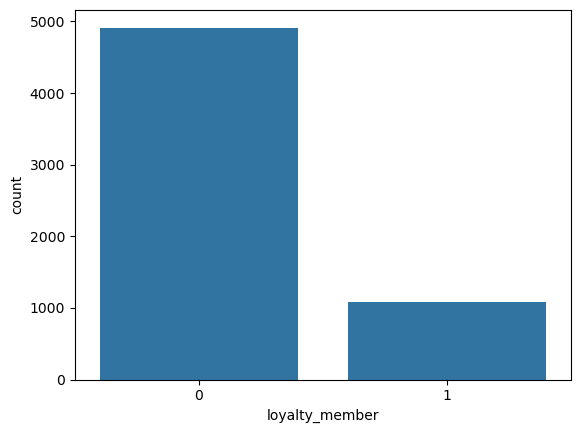

In [25]:
sns.countplot(x='loyalty_member', data=df)
plt.show()

In [29]:
df.groupby('churned').mean(numeric_only=True)

,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index
churned,,,,,,,,,,,,,,
0,31.016170,80.472262,8.841057,20.101952,0.283111,0.069305,0.810885,0.194636,3.172195,0.603167,3.91168,5.345155,8.140284,4.500217
1,29.663079,80.573552,7.074273,81.433800,0.295679,0.083604,1.113025,0.105490,2.555328,0.596315,3.70451,2.364736,7.684553,4.586114


# Univariate Analysis:-

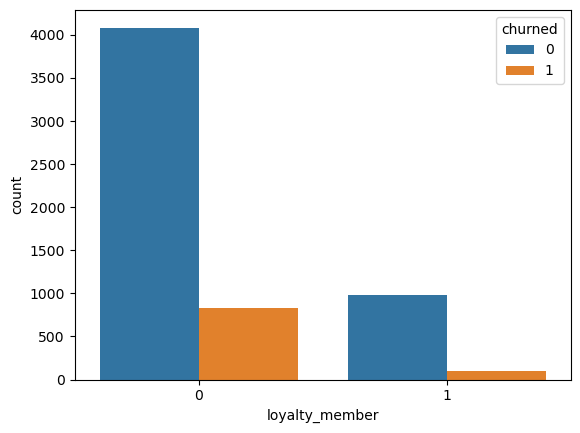

In [30]:
sns.countplot(x='loyalty_member', hue='churned', data=df)
plt.show()

# Identify Numerical Columns:-

In [31]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['account_age_months', 'avg_order_value', 'total_orders',
       'days_since_last_purchase', 'discount_usage_rate', 'return_rate',
       'customer_support_tickets', 'loyalty_member',
       'browsing_frequency_per_week', 'cart_abandonment_rate',
       'product_review_score_avg', 'engagement_score', 'satisfaction_score',
       'price_sensitivity_index', 'churned'],
      dtype='object')

In [34]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols

Index([], dtype='object')

In [35]:
df['discount_usage_rate'].describe()

count    6000.000000
mean        0.285057
std         0.158112
min         0.003000
25%         0.162000
50%         0.265000
75%         0.387000
max         0.895000
Name: discount_usage_rate, dtype: float64

Most features are right-skewed (like total orders)

Some outliers exist in avg order value

Majority customers are non-loyalty members (if applicable)

Churn distribution is imbalanced (if Yes < No)

# Churn Distribution:-

C:\Users\Umesh Chandra\AppData\Local\Temp\ipykernel_36920\159256607.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


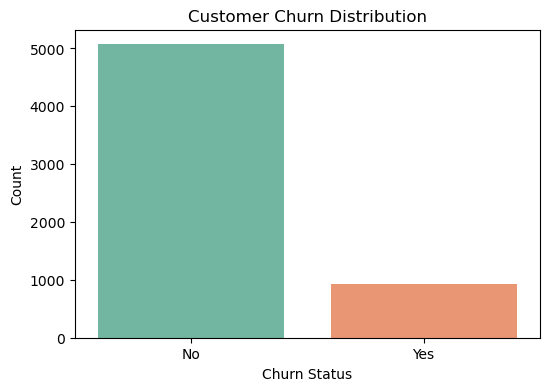

In [6]:
# =========================================
# 1. Churn Distribution
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd .read_csv(r"C:\Users\Umesh Chandra\e commerce (2).csv")
plt.figure(figsize=(6,4))

sns.countplot(
    x='churned',
    data=df,
    palette='Set2'
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Count")

plt.show()

This graph shows:

How many customers stayed

How many customers left (churned)

# Insight:-

Most customers did not churn.

Around 15% customers churned.
    
The dataset is imbalanced.

The company is retaining most customers, but identifying churned customers is still very important.

# Loyalty Member Distribution:-

C:\Users\Umesh Chandra\AppData\Local\Temp\ipykernel_36920\3273401976.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


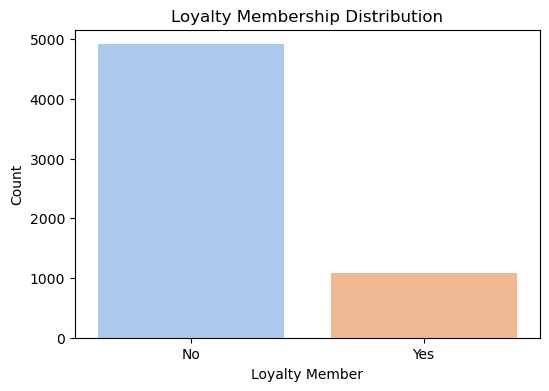

In [7]:
# =========================================
# 2. Loyalty Member Distribution
# =========================================

plt.figure(figsize=(6,4))

sns.countplot(
    x='loyalty_member',
    data=df,
    palette='pastel'
)

plt.title("Loyalty Membership Distribution")
plt.xlabel("Loyalty Member")
plt.ylabel("Count")

plt.show()

# Insight:-

Loyalty membership can help improve customer retention.
    
Loyal customers are usually more connected with the platform.

Loyalty programs can reduce customer churn and increase long-term engagement.

# Avg Order Value Distribution:-

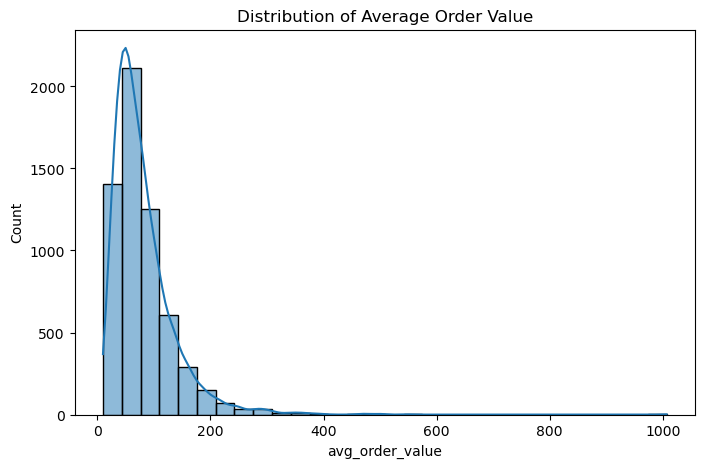

In [8]:
# =========================================
# 3. Avg Order Value Distribution
# =========================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['avg_order_value'],
    kde=True,
    bins=30
)

plt.title("Distribution of Average Order Value")

plt.show()

# What This Graph Shows:-

This graph shows how much customers spend on average.

# Insight
    
Most customers make low to medium-value purchases.
    
A few customers spend very high amounts.
    
The data is right-skewed because of high spenders.
Business Meaning

High-value customers are very important for revenue and should be retained carefully.

# Days Since Last Purchase Distribution:-

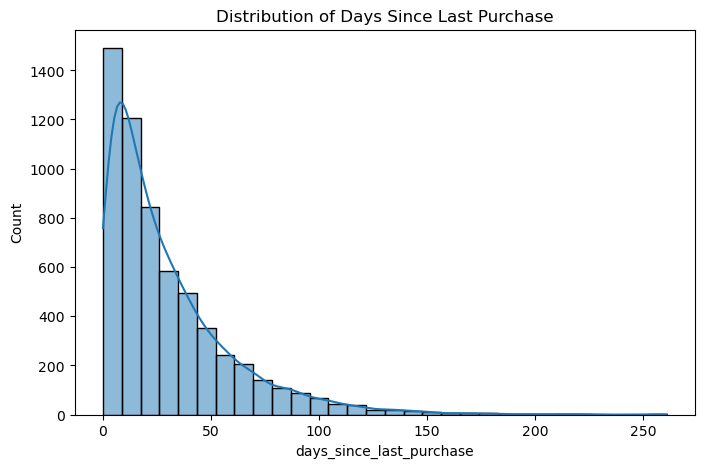

In [9]:
# =========================================
# 4. Days Since Last Purchase Distribution
# =========================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['days_since_last_purchase'],
    kde=True,
    bins=30
)

plt.title("Distribution of Days Since Last Purchase")

plt.show()



This graph shows how long customers have been inactive since their last purchase.

# Insight
    
Most customers purchased recently.

Some customers have been inactive for a long time.


Customers with long inactivity may have a higher chance of churn.

# Engagment score Distribution:

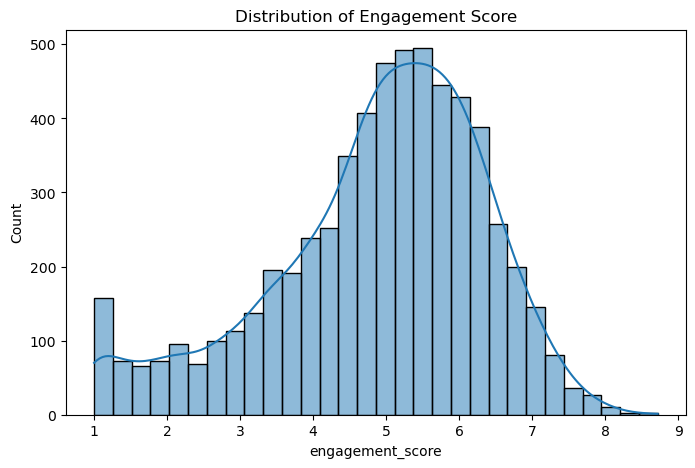

In [10]:
# =========================================
# 5. Engagement Score Distribution
# =========================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['engagement_score'],
    kde=True,
    bins=30
)

plt.title("Distribution of Engagement Score")

plt.show()



This graph shows how actively customers interact with the platform.

# Insight

Most customers have medium engagement.
    
Some customers have low engagement.
    

Low engagement may be an early sign of customer churn.

# Satisfaction Score Distribution:-

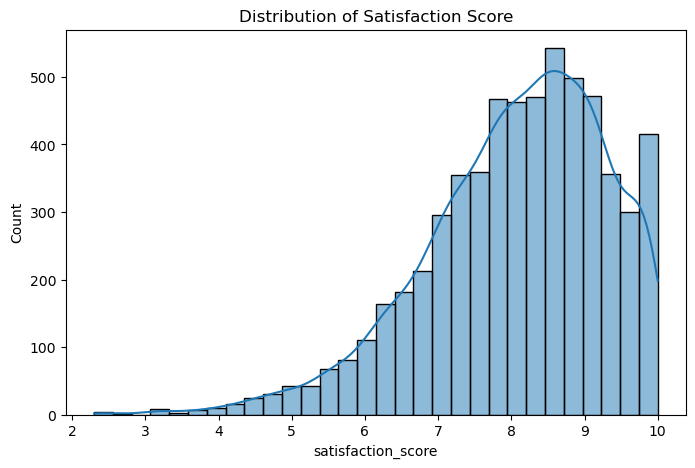

In [11]:
# =========================================
# 6. Satisfaction Score Distribution
# =========================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['satisfaction_score'],
    kde=True,
    bins=30
)

plt.title("Distribution of Satisfaction Score")

plt.show()

This graph shows customer satisfaction levels.

# Insight

Most customers are fairly satisfied.
    
Overall customer experience looks positive.



Satisfied customers are more likely to stay and continue purchasing.

# Cart Abandonment Rate Distribution:-

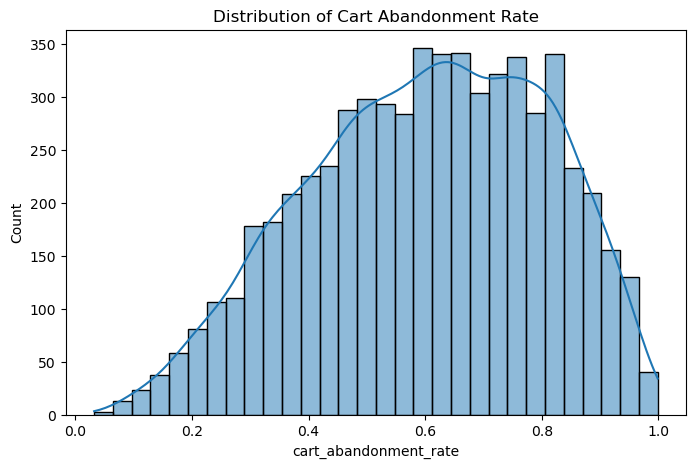

In [12]:
# =========================================
# 7. Cart Abandonment Rate Distribution
# =========================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['cart_abandonment_rate'],
    kde=True,
    bins=30
)

plt.title("Distribution of Cart Abandonment Rate")

plt.show()

This graph shows how often customers leave products in the cart without completing the purchase.

# Insight

Cart abandonment rate is relatively high.

Many customers do not complete the buying process.

Possible reasons may include:
High price
Checkout issues
Delivery charges
Lack of trust
This can strongly affect churn.

 # Price Sensitivity Distribution:-

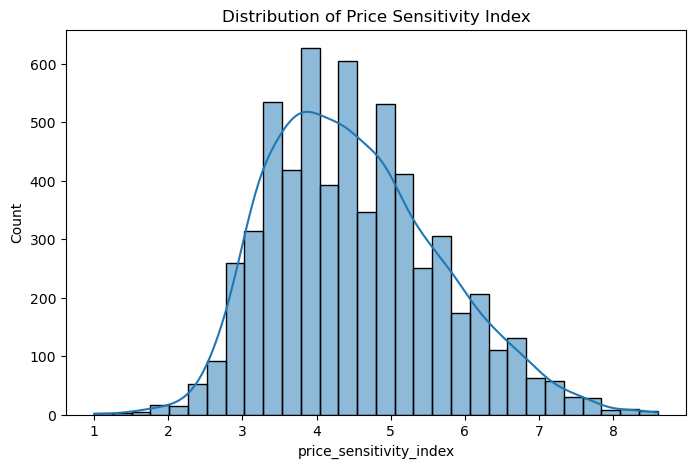

In [13]:
# =========================================
# 8. Price Sensitivity Distribution
# =========================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['price_sensitivity_index'],
    kde=True,
    bins=30
)

plt.title("Distribution of Price Sensitivity Index")

plt.show()

This graph shows how sensitive customers are to prices.

# Insight:-
    
Some customers are highly price-sensitive.

Discounts and offers may strongly influence them.


Price-sensitive customers may easily switch to competitors.

 # Avg Order Value Boxplot:-

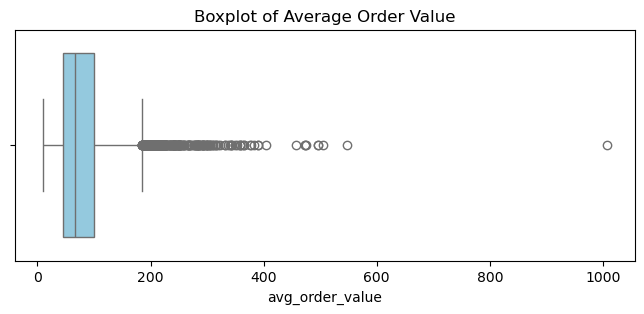

In [14]:
# =========================================
# 9. Avg Order Value Boxplot
# =========================================

plt.figure(figsize=(8,3))

sns.boxplot(
    x=df['avg_order_value'],
    color='skyblue'
)

plt.title("Boxplot of Average Order Value")

plt.show()

This graph shows spending spread and outliers.


Some customers spend extremely high amounts.
    
Outliers are clearly visible.

A premium customer segment exists in the business.

# Total Orders Boxplot

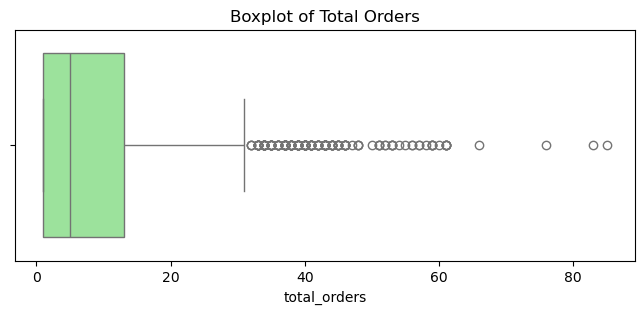

In [15]:
# =========================================
# 10. Total Orders Boxplot
# =========================================

plt.figure(figsize=(8,3))

sns.boxplot(
    x=df['total_orders'],
    color='lightgreen'
)

plt.title("Boxplot of Total Orders")

plt.show()

This graph shows how frequently customers place orders.

# Insight
    
Most customers place only a few orders.
    
Some customers are highly active buyers.


Repeat customers are valuable for business growth.

# Days Since Last Purchase Boxplot

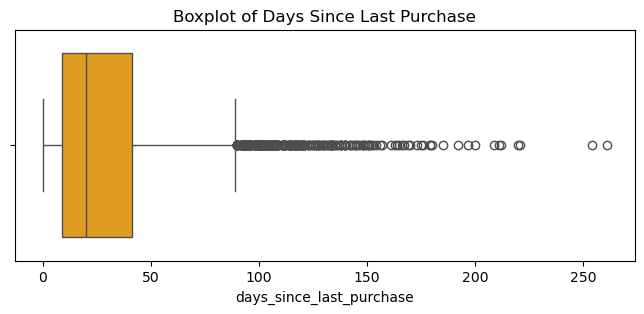

In [16]:
# =========================================
# 11. Days Since Last Purchase Boxplot
# =========================================

plt.figure(figsize=(8,3))

sns.boxplot(
    x=df['days_since_last_purchase'],
    color='orange'
)

plt.title("Boxplot of Days Since Last Purchase")

plt.show()

This graph highlights inactive customers and outliers.


Some customers have been inactive for a very long time.


These customers may need re-engagement campaigns.

# Cart Abandonment Rate Boxplot

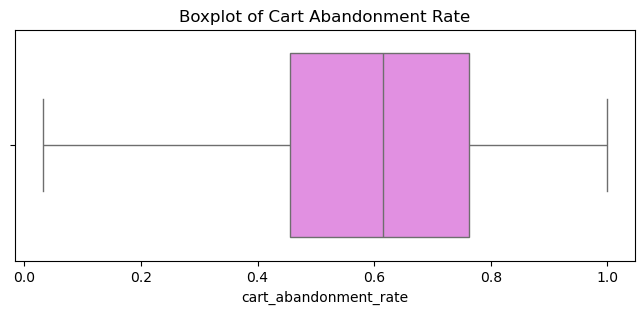

In [17]:
# =========================================
# 12. Cart Abandonment Rate Boxplot
# =========================================

plt.figure(figsize=(8,3))

sns.boxplot(
    x=df['cart_abandonment_rate'],
    color='violet'
)

plt.title("Boxplot of Cart Abandonment Rate")

plt.show()

This graph shows the spread of cart abandonment behavior.

Some users have extremely high cart abandonment rates.

The company may need to improve checkout experience and remarketing strategies.

# Connections

Customers who may churn are likely to have:

High inactivity
High cart abandonment
Low engagement
High price sensitivity

The univariate analysis shows that customer engagement, satisfaction, inactivity, 
and purchase behavior play an important role in customer retention and churn risk.

# Bivariate Analysis:-

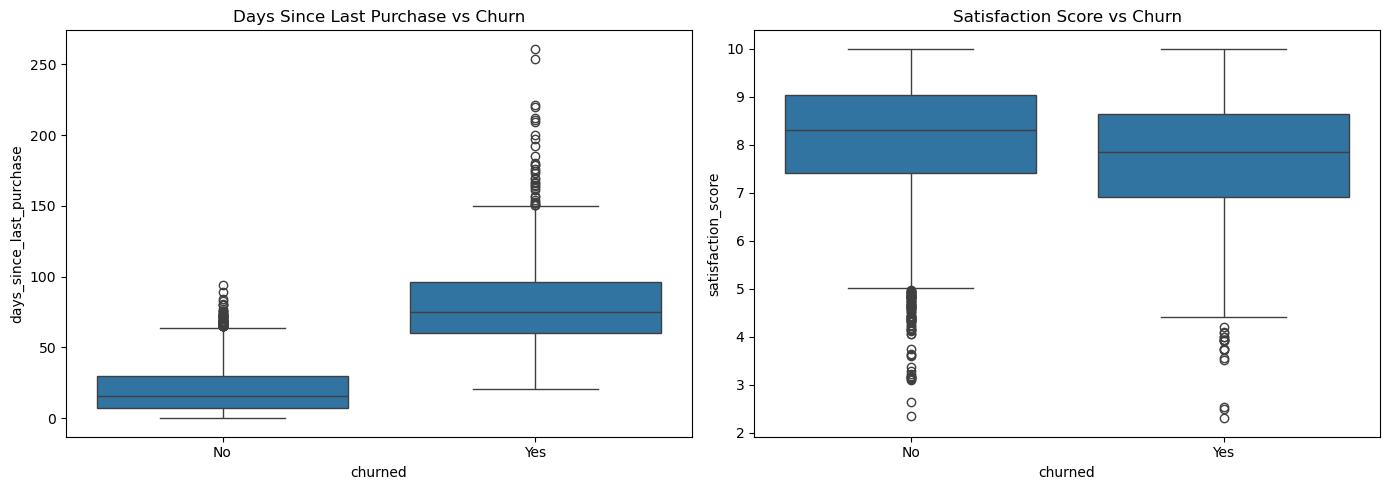

In [20]:
# =========================================
# 1. Days Since Last Purchase vs Churn
# 2. Satisfaction Score vs Churn
# =========================================

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(
    x='churned',
    y='days_since_last_purchase',
    data=df,
    ax=axes[0]
)

axes[0].set_title("Days Since Last Purchase vs Churn")

sns.boxplot(
    x='churned',
    y='satisfaction_score',
    data=df,
    ax=axes[1]
)

axes[1].set_title("Satisfaction Score vs Churn")

plt.tight_layout()
plt.show()

These two graphs explain the connection between:

Customer inactivity

Customer satisfaction

Customer churn


Customers who have not purchased for a long time are more likely to churn.

Churned customers also show lower satisfaction scores.

This means inactive and dissatisfied customers have a higher chance of leaving the platform.

When customers stop interacting and become less satisfied, their loyalty decrease.

The company should:

Identify inactive customers early
Improve customer experience
Send personalized offers and reminders
Increase satisfaction through better service

 # Engagement Score vs Churn & Cart Abandonment Rate vs Churn

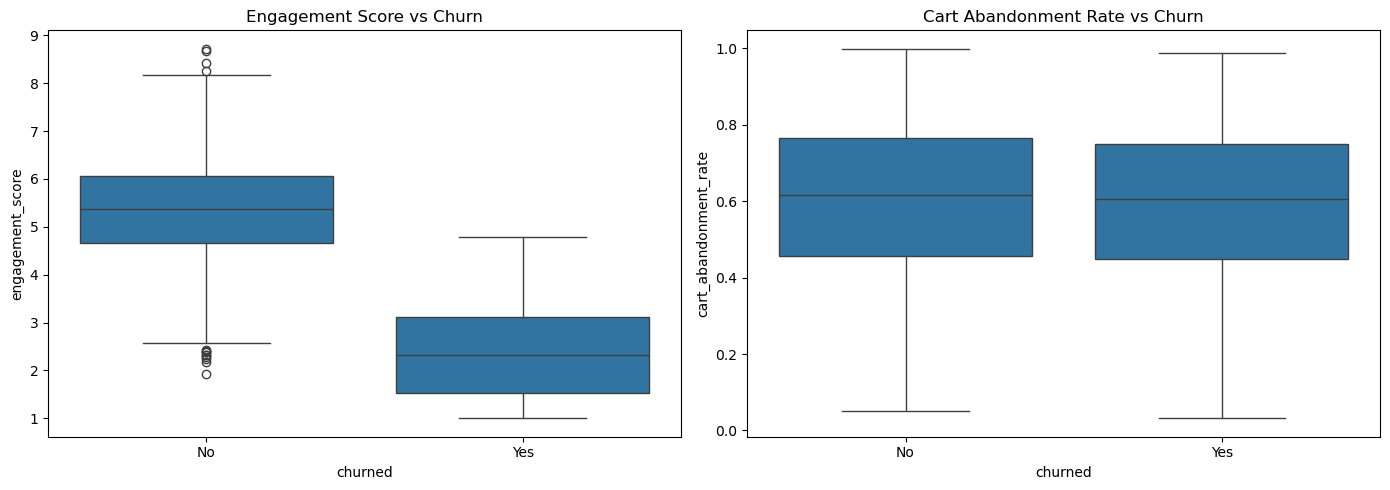

In [21]:
# =========================================
# 3. Engagement Score vs Churn
# 4. Cart Abandonment Rate vs Churn
# =========================================

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(
    x='churned',
    y='engagement_score',
    data=df,
    ax=axes[0]
)

axes[0].set_title("Engagement Score vs Churn")

sns.boxplot(
    x='churned',
    y='cart_abandonment_rate',
    data=df,
    ax=axes[1]
)

axes[1].set_title("Cart Abandonment Rate vs Churn")

plt.tight_layout()
plt.show()

These graphs explain:

How actively customers interact
Whether they complete purchases
Their connection with churn

# Insight

Customers with low engagement are more likely to churn.
    
Customers with high cart abandonment also show higher churn behavior.

This means customers are visiting the platform but not fully completing the buying journey.

# Business Meaning

Customers may lose interest due to:

Poor user experience
Pricing issues
Checkout complexity
Lack of motivation to purchase

The company should:

Improve checkout experience
Send cart reminder notifications
Increase engagement through recommendations and rewards

 # Price Sensitivity vs Churn & Total Orders vs Churn

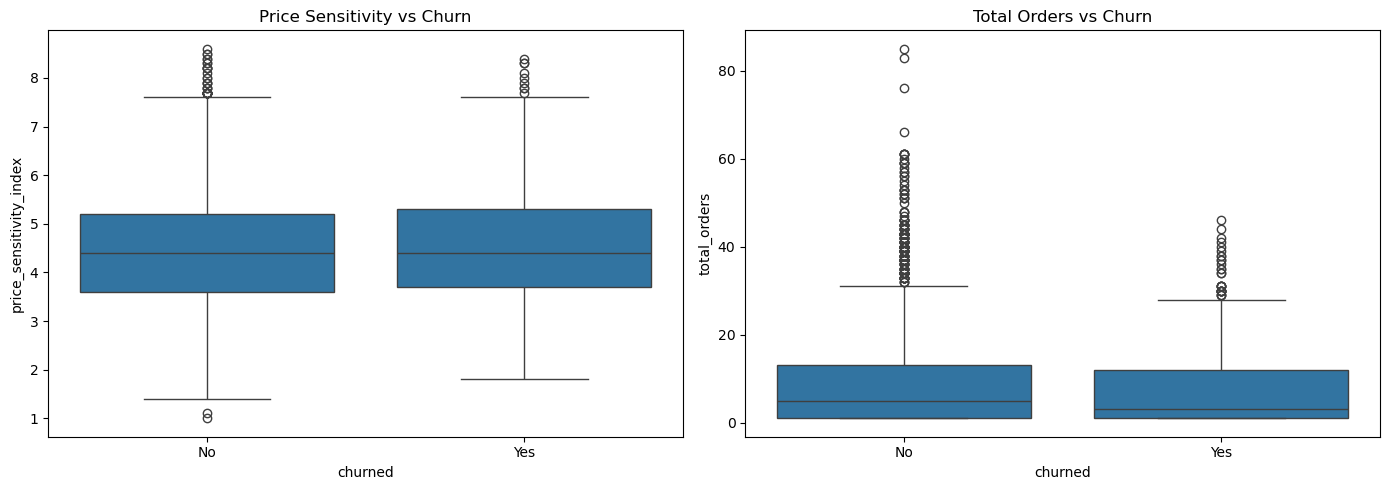

In [22]:
# =========================================
# 5. Price Sensitivity vs Churn
# 6. Total Orders vs Churn
# =========================================

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(
    x='churned',
    y='price_sensitivity_index',
    data=df,
    ax=axes[0]
)

axes[0].set_title("Price Sensitivity vs Churn")

sns.boxplot(
    x='churned',
    y='total_orders',
    data=df,
    ax=axes[1]
)

axes[1].set_title("Total Orders vs Churn")

plt.tight_layout()
plt.show()

These graphs explain the relationship between:

Purchase frequency
Price dependency
Customer churn

# Insight

Customers with high price sensitivity are more likely to churn.

Customers with fewer total orders also show higher churn probability.

This means occasional buyers who depend heavily on discounts are less loyal.


Price-sensitive customers can easily switch to competitors when prices increase or discounts are unavailable.

# Business Action

The company should:

Offer personalized discounts
Encourage repeat purchases
Use loyalty rewards and memberships
Final Observation

Customers with low purchase frequency and high price sensitivity are high-risk churn customers.

# Loyalty Membership vs Churn & customer Support Tickets vs Churn

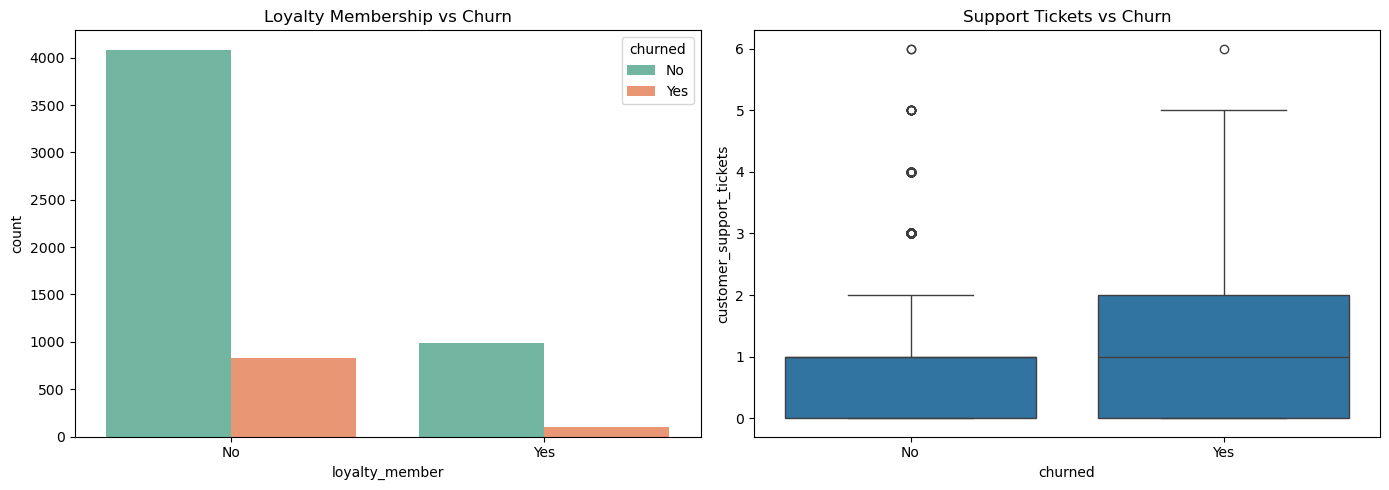

In [23]:
# =========================================
# 7. Loyalty Membership vs Churn
# 8. Customer Support Tickets vs Churn
# =========================================

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.countplot(
    x='loyalty_member',
    hue='churned',
    data=df,
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title("Loyalty Membership vs Churn")

sns.boxplot(
    x='churned',
    y='customer_support_tickets',
    data=df,
    ax=axes[1]
)

axes[1].set_title("Support Tickets vs Churn")

plt.tight_layout()
plt.show()

These graphs explain:

The effect of loyalty programs,
The impact of customer issues,
Their connection with churn

Loyalty members are less likely to churn.
Customers with more support tickets tend to churn more.

This means loyalty improves retention, while unresolved issues increase churn risk.


Customers who feel valued through loyalty benefits stay longer, while frustrated customers are more likely to leave.

connections

The company should:

Strengthen loyalty programs,
Improve customer support response time,
Solve customer issues quickly,
Final Observation

Strong customer relationships reduce churn, while poor support experience increases churn risk.

# Correlation Heatmap

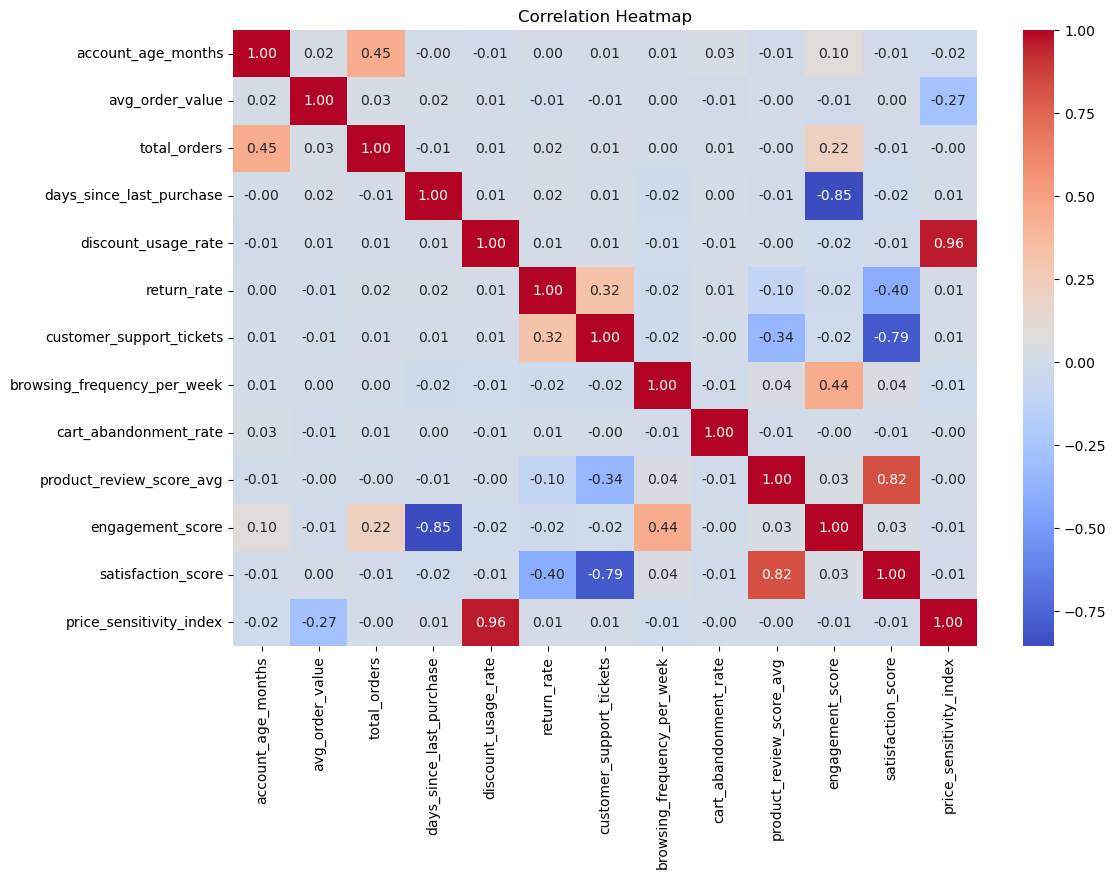

In [24]:
# =========================================
# 9. Correlation Heatmap
# =========================================

plt.figure(figsize=(12,8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

# Insight:-

The heatmap shows how numerical features are related to each other.

Engagement Score ↔ Satisfaction Score

Customers with higher engagement are generally more satisfied.

Days Since Last Purchase ↔ Engagement

Inactive customers usually show lower engagement.

Cart Abandonment ↔ Churn Indicators

Customers who abandon carts frequently are more likely to leave.

Total Orders ↔ Retention

Customers with more orders are more loyal and stable.

# Pattern:-

Customers are more likely to churn when they:

Stay inactive for a long time

Have low satisfaction

Show low engagement

Abandon carts frequently

Are highly price-sensitive

Raise more support issues

Are not loyalty members

The company should focus on customers who are becoming less active on the platform because they are more likely to leave in the future.

# Multivariate Analysis:-

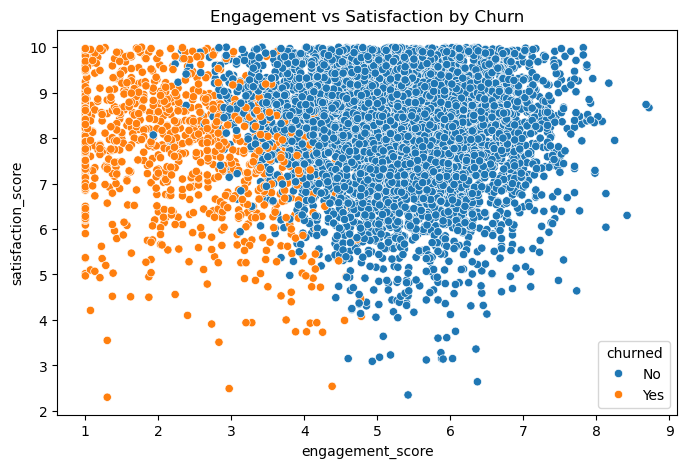

In [25]:
# =========================================
# 1. Engagement Score vs Satisfaction Score
#    colored by Churn
# =========================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='engagement_score',
    y='satisfaction_score',
    hue='churned',
    data=df
)

plt.title("Engagement vs Satisfaction by Churn")

plt.show()

the Graph Says:-

Customers with high engagement mostly have high satisfaction.

Most churned customers are in the low engagement and low satisfaction area.

# Insight

Low engagement + low satisfaction increases churn chances.


Active and happy customers usually stay longer.

# Cart Abandonment vs Last Purchase

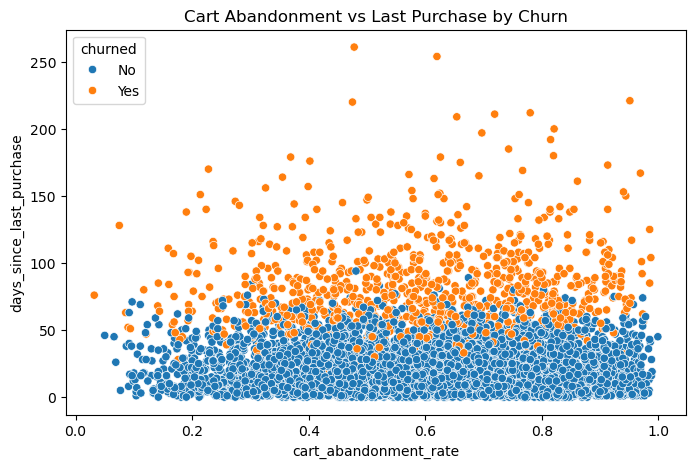

In [26]:
# =========================================
# 2. Cart Abandonment vs Last Purchase
#    colored by Churn
# =========================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='cart_abandonment_rate',
    y='days_since_last_purchase',
    hue='churned',
    data=df
)

plt.title("Cart Abandonment vs Last Purchase by Churn")

plt.show()



Customers with high cart abandonment and long inactivity are mostly churned customers.

# Insight

Inactive customers who do not complete purchases are more likely to leave.

# Business Meaning

Customers are losing buying interest.

# Price Sensitivity vs Avg Order Value

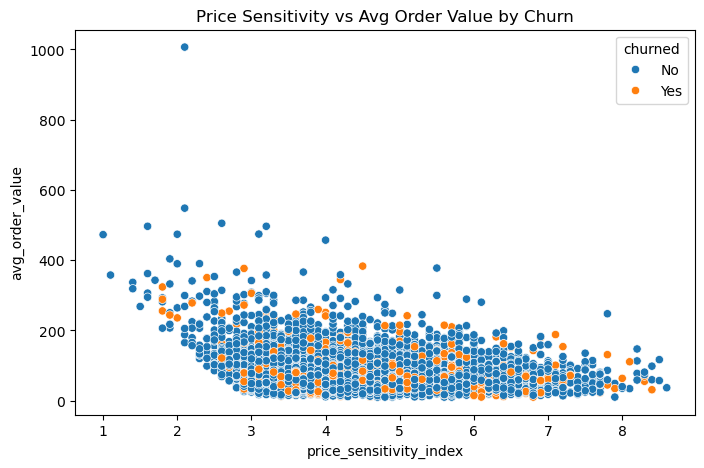

In [27]:
# =========================================
# 3. Price Sensitivity vs Avg Order Value
#    colored by Churn
# =========================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='price_sensitivity_index',
    y='avg_order_value',
    hue='churned',
    data=df
)

plt.title("Price Sensitivity vs Avg Order Value by Churn")

plt.show()



Highly price-sensitive customers show more churn behavior.

# Insight

Customers who care too much about price can easily leave.


Better offers and discounts may help retain them.

# Pairplot of Important Features

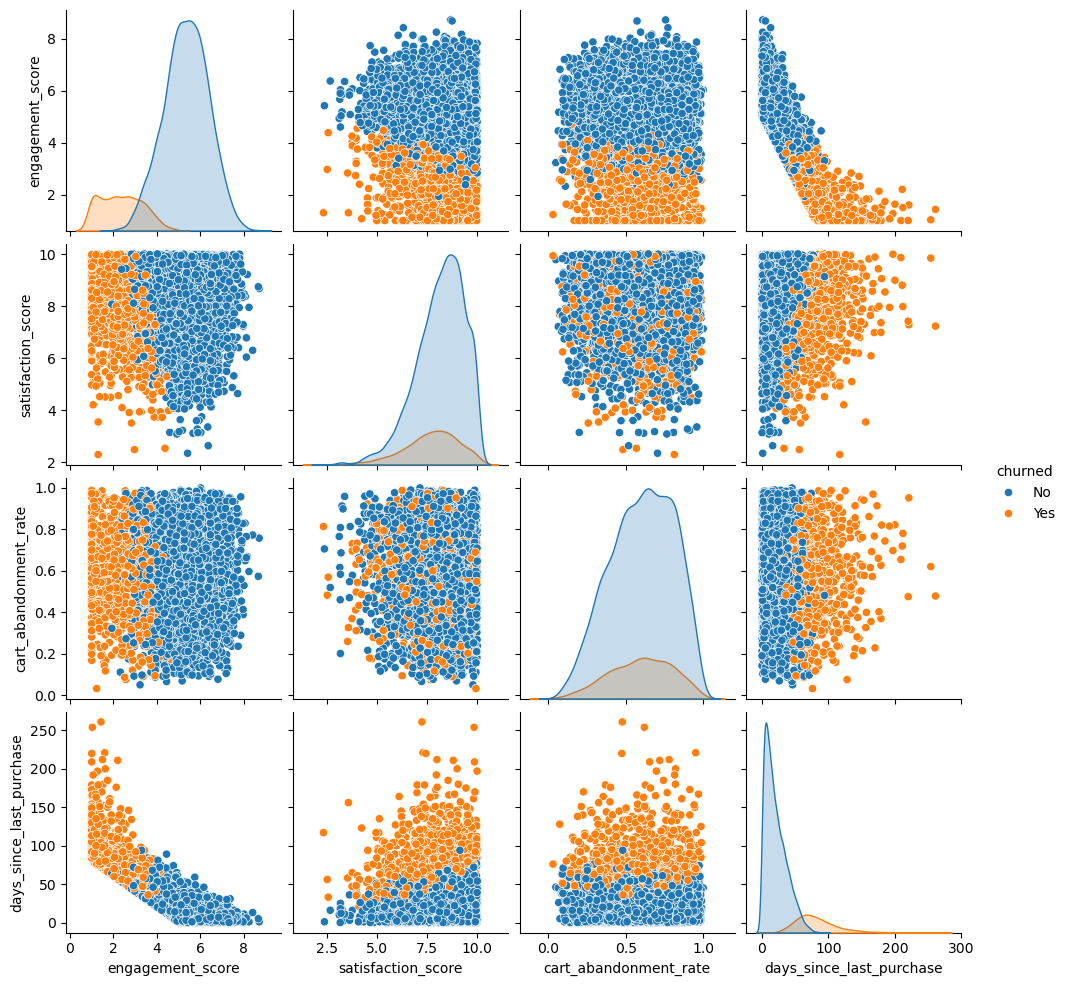

In [29]:
# =========================================
# 4. Pairplot of Important Features
# =========================================

selected_cols = [
    'engagement_score',
    'satisfaction_score',
    'cart_abandonment_rate',
    'days_since_last_purchase',
    'churned'
]

sns.pairplot(
    df[selected_cols],
    hue='churned'
)

plt.show()

 the Graph Says

Churned customers mostly appear in:

Low engagement

Low satisfaction

High inactivity

High cart abandonment areas

# Insight

Multiple negative behaviors together increase churn risk.


The company should identify these risky customers early.

# pattern:-

# Inactive Customers

1.Customers who have not purchased for a long time are more likely to churn.

# 2. Low Engagement Pattern

Customers with low engagement scores show higher churn chances.

# 3. Low Satisfaction Pattern

Unsatisfied customers are more likely to leave the platform.

# 4. High Cart Abandonment Pattern

Customers who frequently leave products in the cart often churn later.

# 5. High Price Sensitivity Pattern

Customers who depend heavily on discounts can easily switch to competitors.

# 6. Low Purchase Frequency Pattern

Customers with fewer total orders are less loyal and more likely to churn.

# 7. Weak Loyalty & Support Issue Pattern

Non-loyalty members and customers with more support complaints show higher churn risk.

# SUMMARY:-

The analysis shows that customer behavior, engagement, satisfaction, and purchasing activity strongly affect customer churn.

Most retained customers are:

Active users
More engaged
More satisfied
Frequent buyers
Loyalty members

Churned customers mostly show:

High inactivity
Low engagement
Low satisfaction
High cart abandonment
High price sensitivity
Fewer purchases

The analysis also shows that customers with more support issues are more likely to leave the platform.

# Conclussion:-

Customers who are inactive, less engaged, dissatisfied, highly price-sensitive, and frequently abandon carts have a higher chance of churn.
The company should improve customer engagement, loyalty programs, customer support, and personalized offers to reduce churn and improve customer retention.

In [ ]:
# Final Conclusion

- Low engagement customers churn more.
- High cart abandonment affects retention.
- Loyalty members retain longer.
- Satisfaction score impacts churn behavior.